# 01 — Exploratory Data Analysis

Exploration of the synthetic AI maturity dataset.

**Goals:**
1. Confirm the synthetic data has realistic distributions per sector.
2. Verify within-dimension correlations (questions in the same dimension move together).
3. Inspect cross-dimension relationships.
4. Identify any artifacts before model training.

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, str(Path('..').resolve()))
from backend.ml.framework import FRAMEWORK

DATA_PATH = Path('..') / 'data' / 'synthetic' / 'synthetic_companies.csv'
df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
df.head()

Shape: (1000, 34)


,sector,size,is_outlier,d1_q1,d1_q2,d1_q3,d1_q4,d1_q5,d2_q1,d2_q2,...,d5_q2,d5_q3,d5_q4,d5_q5,dim_avg_data,dim_avg_talent,dim_avg_technology,dim_avg_strategy,dim_avg_processes,maturity_score
0,manufacturing,startup,False,2,4,2,3,1,1,2,...,3,3,3,3,2.4,1.8,2.6,1.8,2.8,2.26
1,banking_insurance,startup,False,3,3,3,2,3,2,2,...,4,3,3,2,2.8,2.2,2.4,2.6,2.8,2.56
2,tech_software,medium,False,4,5,5,4,5,4,5,...,4,3,4,3,4.6,4.6,3.8,4.2,3.2,4.15
3,fintech,large,False,5,4,5,4,3,3,3,...,4,3,3,3,4.2,3.6,3.0,3.2,3.2,3.49
4,manufacturing,large,False,2,4,4,3,3,4,2,...,3,4,2,3,3.2,2.6,3.4,2.4,2.8,2.90


## Score distribution

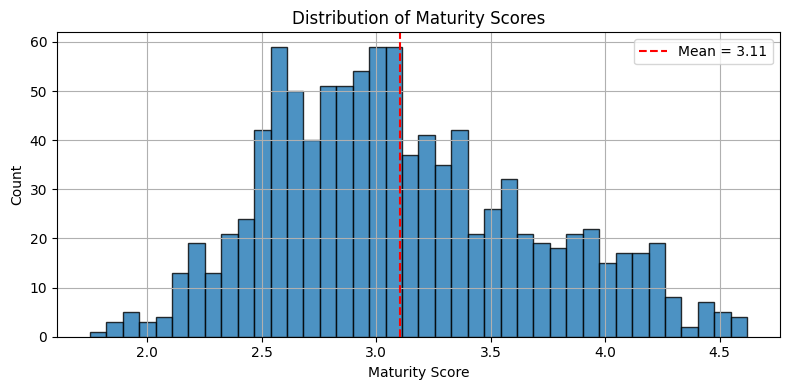

In [2]:
fig, ax = plt.subplots(figsize=(8, 4))
df['maturity_score'].hist(bins=40, ax=ax, edgecolor='black', alpha=0.8)
ax.axvline(df['maturity_score'].mean(), color='red', linestyle='--', label=f'Mean = {df["maturity_score"].mean():.2f}')
ax.set_xlabel('Maturity Score')
ax.set_ylabel('Count')
ax.set_title('Distribution of Maturity Scores')
ax.legend()
plt.tight_layout()
plt.show()

## Distribution by sector

/tmp/ipykernel_385/3604313006.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


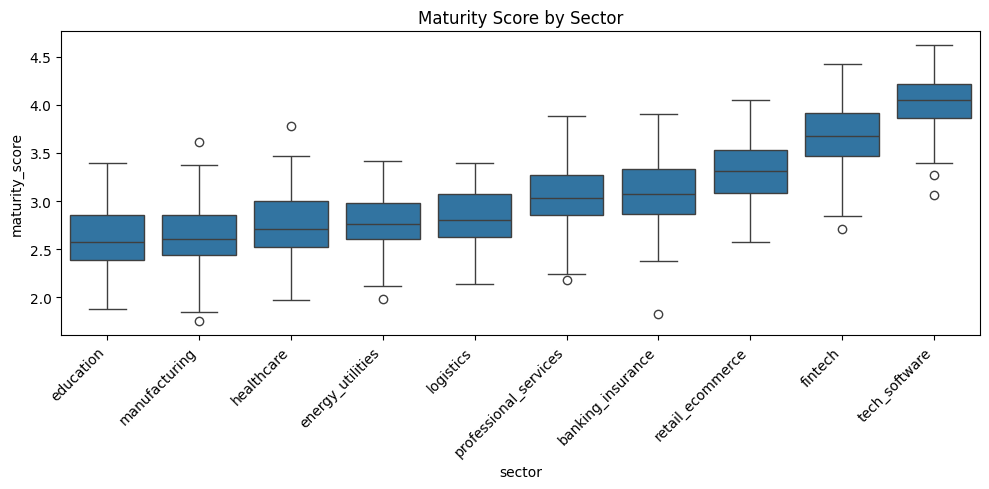

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
order = df.groupby('sector')['maturity_score'].mean().sort_values().index
sns.boxplot(data=df, x='sector', y='maturity_score', order=order, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title('Maturity Score by Sector')
plt.tight_layout()
plt.show()

## Within-dimension correlations

We expect questions inside the same dimension to be moderately correlated.

In [4]:
for dim in FRAMEWORK:
    qids = [s.question.id for s in dim.sub_dimensions]
    corr = df[qids].corr()
    print(f'{dim.name}: avg pairwise correlation = {corr.where(~np.eye(len(corr), dtype=bool)).stack().mean():.2f}')

Data: avg pairwise correlation = 0.55
Talent & Culture: avg pairwise correlation = 0.58
Technology: avg pairwise correlation = 0.55
Strategy: avg pairwise correlation = 0.49
Processes: avg pairwise correlation = 0.44


## Cross-dimension correlation (using the dimension averages)

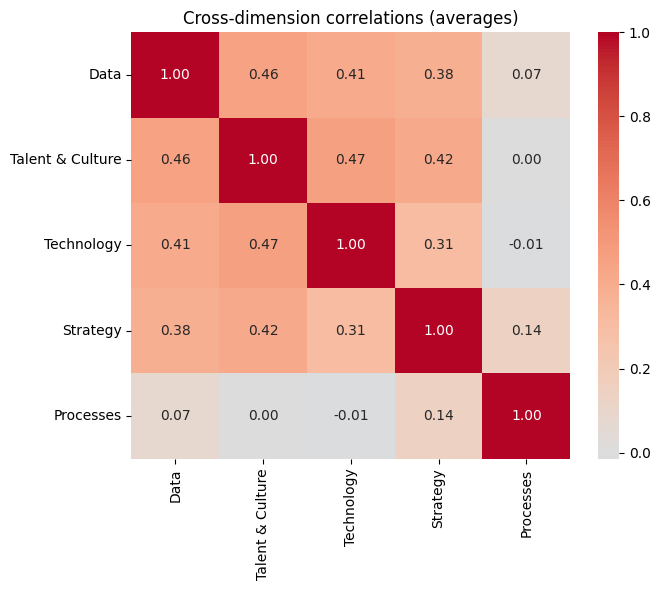

In [5]:
dim_cols = [f'dim_avg_{d.id}' for d in FRAMEWORK]
corr = df[dim_cols].corr()
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax,
            xticklabels=[d.name for d in FRAMEWORK],
            yticklabels=[d.name for d in FRAMEWORK])
ax.set_title('Cross-dimension correlations (averages)')
plt.tight_layout()
plt.show()